# Tracking the Perseid Radiant with Astropy
### A first introduction to a real astronomy library + the Python prototype for the Perseid mini-project

This notebook does two things at once:

1. **Teaches Astropy from scratch** — before each piece of code, we answer "why do we need this object, what does it represent?"
2. **Builds the real prototype** — we compute the Perseid radiant's position in the sky throughout the night of August 12–13, 2026, from Akçay/Balıkesir, and use it to validate the accuracy of our live JS tool.

First a bit of physics, then the code.

## 1. The physics of a meteor shower: why does a radiant exist?

The Perseid meteor shower comes from dust and ice particles left behind by **Comet Swift-Tuttle** along its orbit. Every year in mid-August, Earth passes through this debris trail. The particles hit the atmosphere at roughly 59 km/s and burn up from friction — that's the "shooting star" we see.

**So what is the radiant?** These particles all travel through space on nearly parallel paths (since they all originate from the same comet's orbit). Parallel lines appear to converge to a single point in perspective — the same way a straight highway appears to vanish to a point on the horizon. That apparent point of origin for the meteors is the **radiant**. For the Perseids, it sits in the constellation Perseus.

**An important distinction:**
- **Radiant position** → a fixed point in the sky (in Perseus), but it *rises, climbs, and sets* over the course of the night (because Earth rotates)
- **Shower peak** → the calendar moment when Earth passes through the densest part of the debris trail (Aug 12–13), *independent of location*
- **Our "best hour"** → the intersection of the two: on peak night, the moment the radiant climbs highest *from your specific location*

We need Astropy to compute that third thing.

In [1]:
# Astropy's three core modules — we'll get to know each one
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from astropy import units as u
from astropy.time import Time
from astropy.coordinates import (
    EarthLocation, SkyCoord, AltAz, get_sun, get_body
)

plt.rcParams['figure.facecolor'] = '#0B1120'
plt.rcParams['axes.facecolor'] = '#141d33'
plt.rcParams['text.color'] = '#F4EFE6'
plt.rcParams['axes.labelcolor'] = '#F4EFE6'
plt.rcParams['xtick.color'] = '#8B96B8'
plt.rcParams['ytick.color'] = '#8B96B8'
plt.rcParams['axes.edgecolor'] = '#2A3554'
plt.rcParams['grid.color'] = '#2A3554'

print("Astropy is ready — units and time modules loaded.")

Astropy is ready — units and time modules loaded.


## 2. `astropy.units` — why does every number carry a unit?

In Astropy you don't work with bare numbers (like `58.1`) — you attach a unit to every value (`58.1 * u.deg`). The reason is simple: astronomy juggles many angle units at once (degrees, radians, hour angle, arcseconds), and converting between them by hand is a classic source of bugs. Astropy converts automatically and catches unit mismatches (like accidentally mixing degrees and radians) before your code even runs.

## 3. `EarthLocation` — defining where you're standing

How an object in the sky looks *to you* — how high above the horizon, in which direction — depends entirely on where you're standing. `EarthLocation` turns a latitude/longitude/elevation into an observer point Astropy understands.

In [2]:
# Akçay / Balıkesir coastal area (approximate coordinates)
akcay = EarthLocation(lat=39.5822*u.deg, lon=26.9186*u.deg, height=10*u.m)

print(f"Latitude : {akcay.lat}")
print(f"Longitude: {akcay.lon}")
print(f"Elevation: {akcay.height}")

Latitude : 39.58220000000001 deg
Longitude: 26.9186 deg
Elevation: 9.999999998531305 m


## 4. `Time` — why astronomy always speaks UTC

Observation calculations need a single universal time reference, or time zones turn into a mess. Astropy's `Time` object is UTC-based and can convert automatically to astronomical time formats like Julian Date and sidereal time — we'll see why the latter matters in a moment.

For the peak night of August 12–13, 2026, let's build a 200-point time array from 18:00 UTC (~21:00 local) through 08:00 UTC the next morning (~11:00 local).

In [3]:
night_start = Time("2026-08-12 18:00:00", scale="utc")
night_end   = Time("2026-08-13 08:00:00", scale="utc")

# 200 evenly spaced time points — like frames of a film through the night
times = night_start + (night_end - night_start) * np.linspace(0, 1, 200)

print(f"Start (UTC): {times[0].iso}")
print(f"End   (UTC): {times[-1].iso}")
print(f"Total points: {len(times)}")

Start (UTC): 2026-08-12 18:00:00.000
End   (UTC): 2026-08-13 08:00:00.000
Total points: 200


## 5. `SkyCoord` — how do we define the radiant in the sky

Stars (and fixed sky points like a radiant) are described using **Right Ascension (RA)** and **Declination (Dec)** — think of these as the sky's own "latitude/longitude," but defined in a reference frame that's independent of Earth's rotation (the equatorial coordinate system).

The Perseid radiant's RA/Dec drifts very slightly through August (as Earth moves along its orbit). For peak night we'll use a value close to the IMO (International Meteor Organization) reference: **RA ≈ 3h 13m (48.2°), Dec ≈ +58.1°** — in the northern part of Perseus.

In [4]:
radiant = SkyCoord(ra=48.2*u.deg, dec=58.1*u.deg, frame='icrs')

print(f"Radiant RA : {radiant.ra.to_string(u.hour)}")
print(f"Radiant Dec: {radiant.dec.to_string(u.deg)}")

Radiant RA : 3h12m48s
Radiant Dec: 58d06m00s


## 6. `AltAz` — answering "from where you stand, right now"

RA/Dec is fixed, but what we actually want to know is "how high above the horizon, in which direction" (altitude/azimuth = **Alt/Az**) — and that depends on both location *and* time, because Earth rotates.

The physics behind this transform is **Local Sidereal Time**: a clock that measures how far Earth has rotated relative to the stars (about 4 minutes shorter than a solar day, because Earth is both spinning on its axis and orbiting the Sun). Astropy computes this internally inside the `AltAz` frame — we just say "convert this RA/Dec to Alt/Az, from this location, at this time."\n

In [5]:
altaz_frame = AltAz(obstime=times, location=akcay)
radiant_altaz = radiant.transform_to(altaz_frame)

altitudes = radiant_altaz.alt.deg
azimuths  = radiant_altaz.az.deg

print(f"Radiant altitude at start of night : {altitudes[0]:.1f}°")
print(f"Radiant altitude at middle of night: {altitudes[100]:.1f}°")
print(f"Radiant altitude at end of night   : {altitudes[-1]:.1f}°")
print(f"\nHighest point: {altitudes.max():.1f}° (index {altitudes.argmax()})")

Radiant altitude at start of night : 10.8°
Radiant altitude at middle of night: 56.1°
Radiant altitude at end of night   : 48.1°

Highest point: 71.4° (index 142)


## 7. Where's the Sun? — Astronomical twilight

Even if the radiant is high, you won't see meteors if the sky is bright. The standard astronomical threshold for "dark": **the Sun is more than 18° below the horizon** (astronomical twilight has ended). The `get_sun` function computes the Sun's RA/Dec for us automatically — we run it through the same AltAz transform.

In [6]:
sun = get_sun(times)
sun_altaz = sun.transform_to(altaz_frame)
sun_alt = sun_altaz.alt.deg

dark_mask = sun_alt < -18
print(f"Number of points in astronomical darkness: {dark_mask.sum()} / {len(times)}")
print(f"Darkness begins: {times[dark_mask][0].iso} UTC")
print(f"Darkness ends  : {times[dark_mask][-1].iso} UTC")

Number of points in astronomical darkness: 97 / 200
Darkness begins: 2026-08-12 18:54:52.462 UTC
Darkness ends  : 2026-08-13 01:40:06.030 UTC


## 8. Finding the best viewing window

Now we can combine both conditions: **sky is dark AND radiant is as high as possible**. The highest point where both hold true is our "peak hour".


In [7]:
valid = dark_mask & (altitudes > 0)
best_idx = np.argmax(np.where(valid, altitudes, -999))

best_time = times[best_idx]
best_alt = altitudes[best_idx]
best_az = azimuths[best_idx]

# Simple azimuth-to-compass converter
def az_to_compass(az):
    dirs = ['N','NNE','NE','ENE','E','ESE','SE','SSE','S','SSW','SW','WSW','W','WNW','NW','NNW']
    return dirs[int(round(az/22.5)) % 16]

print("=" * 40)
print(f"BEST VIEWING MOMENT (UTC): {best_time.iso}")
print(f"Radiant altitude          : {best_alt:.1f}°")
print(f"Direction to look          : {az_to_compass(best_az)} ({best_az:.0f}°)")
print("=" * 40)

BEST VIEWING MOMENT (UTC): 2026-08-13 01:40:06.030
Radiant altitude          : 60.8°
Direction to look          : NE (39°)


## 9. Visualization 1 — Altitude vs. time curve

Let's plot the radiant's climb through the night, shade the dark region, and mark the best moment. This is a manual version of what astroplan's `plot_altitude` does in one line — let's see how it works by hand first, then show astroplan's shortcut.

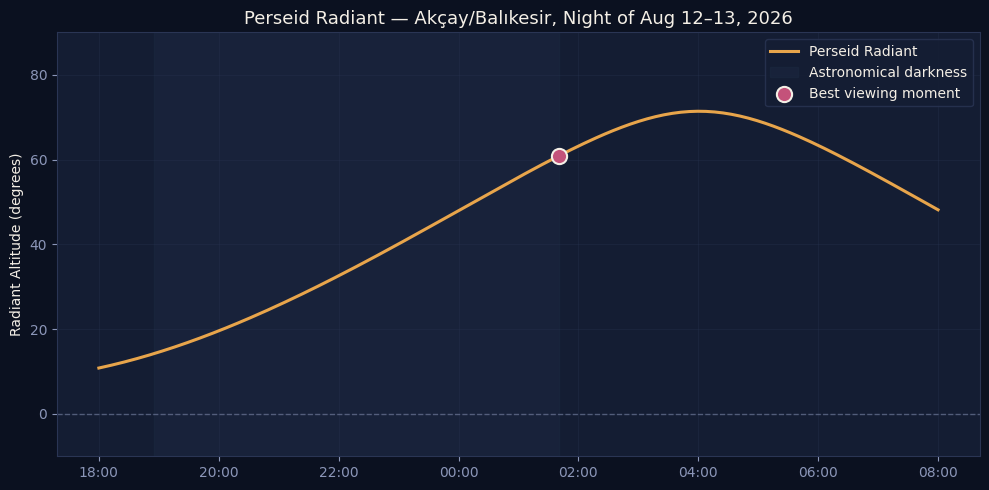

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

times_dt = times.datetime
ax.plot(times_dt, altitudes, color='#E8A54B', linewidth=2.2, label='Perseid Radiant')
ax.axhline(0, color='#8B96B8', linewidth=1, linestyle='--', alpha=0.5)

# shade the dark region
ax.fill_between(times_dt, -10, 90, where=dark_mask, color='#1B2740', alpha=0.6, label='Astronomical darkness')

# mark the best moment
ax.scatter([times_dt[best_idx]], [best_alt], color='#C4527A', s=120, zorder=5,
           edgecolor='#F4EFE6', linewidth=1.5, label='Best viewing moment')

ax.set_ylim(-10, 90)
ax.set_ylabel('Radiant Altitude (degrees)')
ax.set_title('Perseid Radiant — Akçay/Balıkesir, Night of Aug 12–13, 2026', color='#F4EFE6', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend(facecolor='#141d33', edgecolor='#2A3554', labelcolor='#F4EFE6')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('altitude_curve_en.png', dpi=130, facecolor=fig.get_facecolor())
plt.show()

## 10. `astroplan` — ready-made tools for observation planning

`astropy` itself doesn't do plotting, but its official companion package **astroplan** exists exactly for this: observatory scheduling, "when does this target rise/set," and ready-made sky charts. Two functions are especially useful for us:

- `plot_altitude()` — produces the plot we drew by hand above, in one line, and automatically shades day/night
- `plot_sky()` — a **polar sky map**: puts the observer at the center and shows the arc the target traces across the sky through the night — this is exactly the visual inspiration behind our JS tool's dial

`Observer` wraps an `EarthLocation` to give these functions an "observer" context. `FixedTarget` names a `SkyCoord` so astroplan's functions can work with it directly.

In [9]:
from astroplan import Observer, FixedTarget
from astroplan.plots import plot_sky, plot_altitude

observer = Observer(location=akcay, name="Akçay/Balıkesir")
target = FixedTarget(coord=radiant, name="Perseid Radiant")

print(f"Observer: {observer.name}")
print(f"Target  : {target.name}  (RA={target.ra.to_string(u.hour)}, Dec={target.dec.to_string(u.deg)})")

Observer: Akçay/Balıkesir
Target  : Perseid Radiant  (RA=3h12m48s, Dec=58d06m00s)


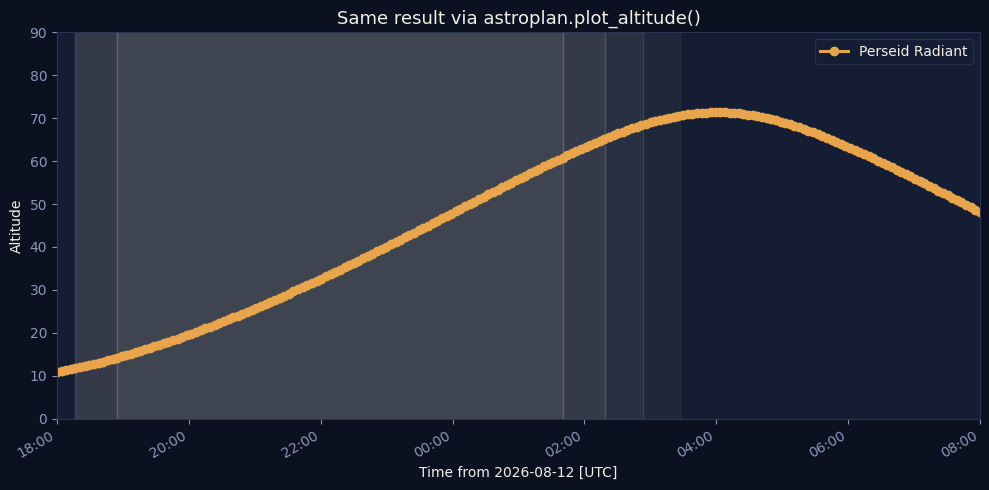

In [10]:
# Same altitude plot with astroplan — a single function call
fig, ax = plt.subplots(figsize=(10, 5))

plot_altitude(target, observer, times, ax=ax, brightness_shading=True,
              style_kwargs={'color': '#E8A54B', 'linewidth': 2.2})

ax.set_title('Same result via astroplan.plot_altitude()', color='#F4EFE6', fontsize=13)
ax.legend(facecolor='#141d33', edgecolor='#2A3554', labelcolor='#F4EFE6')
plt.tight_layout()
plt.savefig('astroplan_altitude_en.png', dpi=130, facecolor=fig.get_facecolor())
plt.show()

## 11. Visualization 2 — Polar sky map

Now for the best part: `plot_sky`. This plot puts you (the observer) at the center and shows, in polar coordinates, the arc the radiant traces across the sky through the night — outer circle is the horizon, center is the zenith (straight up). The color gradient represents time.

This is *exactly* the visual logic our JS tool's dial is built on — here we see astroplan's ready-made version, then we'll redraw it by hand (in canvas/SVG).

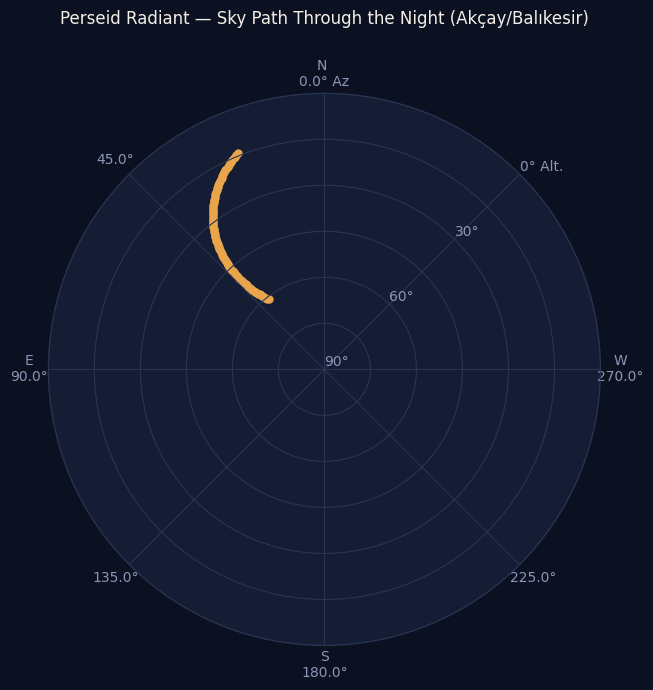

In [11]:
fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111, projection='polar')

# only show the dark hours, so daylight doesn't clutter the map
dark_times = times[dark_mask]

plot_sky(target, observer, dark_times, ax=ax,
         style_kwargs={'color': '#E8A54B', 's': 25})

ax.set_title('Perseid Radiant — Sky Path Through the Night (Akçay/Balıkesir)',
              color='#F4EFE6', fontsize=12, pad=25)
ax.tick_params(colors='#8B96B8')

plt.tight_layout()
plt.savefig('sky_path_polar_en.png', dpi=130, facecolor=fig.get_facecolor())
plt.show()

## 12. Moon phase — the final layer

Moon brightness directly affects viewing quality too. `get_body("moon", ...)` gives the Moon's position; to get its illumination fraction we'll use a simple approach based on the Moon–Sun–Earth geometry (the exact phase-angle calculation isn't built directly into `astropy`, but it's easy to derive from the ecliptic longitude difference between the Moon and the Sun).

In [12]:
moon = get_body("moon", best_time)
sun_at_best = get_sun(best_time)

# rough illumination fraction from the Moon-Sun elongation angle
elongation = moon.separation(sun_at_best)
illum_fraction = (1 - np.cos(elongation.rad)) / 2

print(f"Moon illumination on peak night: {illum_fraction*100:.1f}%")
print("(Should be close to 0% around new moon — which is exactly the case for Perseid 2026)")

Moon illumination on peak night: 0.2%
(Should be close to 0% around new moon — which is exactly the case for Perseid 2026)


## 13. Summary — values to carry over to the JS tool

This prototype confirmed two things:

1. **Is the math right?** — Astropy's built-in, well-tested `AltAz` transform should agree with the Local Sidereal Time formula we write in JS. Compare the numbers below against the JS prototype.
2. **Is the visual language right?** — The arc `plot_sky` produces became the design reference for our JS dial.

Next step: port these three functions (`raDecToAltAz`, the twilight check, the moon phase) to JavaScript — which we already did, so this notebook is our verification pass.

In [13]:
print("PERSEID 2026 — AKÇAY/BALIKESIR SUMMARY")
print("-" * 42)
print(f"Best viewing time (UTC)        : {best_time.iso}")
print(f"Best viewing time (local, UTC+3): {(best_time + 3*u.hour).iso}")
print(f"Radiant altitude               : {best_alt:.1f}°")
print(f"Direction to look               : {az_to_compass(best_az)} ({best_az:.0f}°)")
print(f"Moon illumination               : {illum_fraction*100:.1f}%")
print(f"Astronomical darkness duration  : {dark_mask.sum() * (times[1]-times[0]).to(u.minute):.0f}")

PERSEID 2026 — AKÇAY/BALIKESIR SUMMARY
------------------------------------------
Best viewing time (UTC)        : 2026-08-13 01:40:06.030
Best viewing time (local, UTC+3): 2026-08-13 04:40:06.030
Radiant altitude               : 60.8°
Direction to look               : NE (39°)
Moon illumination               : 0.2%
Astronomical darkness duration  : 409 min
